In [1]:
import sys

sys.path.insert(0, "/home/rebeccaz/Github/vampires_calibration")

import instruments as inst
import copy
import numpy as np
import json

# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "750-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [3]:
# This copied legacy cell used to load a 720 nm .npy start vector.
# The 750 nm fixed-EM IMR-offset fit starts from the JSON file in the next cell.

In [4]:
# Loading in previous fit from vampires_calibration
filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/750-50_restrictive_HWP_FLC_no_IMR_offset_fixed_EM_gain_with_dichroic_best_fit.txt"
with open(filename, "r") as f:
    past_fit = json.load(f)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
# Start from zero when the previous no-offset fit has no IMR offset saved.
offset_derot = np.clip(past_fit.get("image_rotator", {}).get("delta_theta", 0), -1, 1)
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
# em_gain = past_fit["wollaston"]["transmission_ratio"]
em_gain = 0.9937459726763582 # from the dark-subtracted images

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.64  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {'phi': 0, 'epsilon': 0, 'theta': 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {'phi': delta_opts, 'epsilon': epsilon_opts, 'theta': rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": offset_derot},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)

{'dichroic': {'phi': -0.15060529133346875, 'epsilon': 0.2947260746883915, 'theta': 35.808129724830195}, 'flc': {'phi': 3.5231674749347714, 'delta_theta': 2.547063907771257}, 'optics': {'phi': 0.8366868576245823, 'epsilon': 3.887450379959534e-09, 'theta': -59.919309379978884}, 'image_rotator': {'phi': 3.0680237129197785}, 'hwp': {'phi': 2.9838983981947838, 'delta_theta': 0.5155838549975353}, 'lp': {'theta': 0.674229408746958}}
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 0.9937459726763582}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.5231674749347714, 'theta': 0, 'delta_theta': 2.547063907771257}}, 'optics': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0.8366868576245823, 'epsilon': 3.887450379959534e-09, 'theta': -59.919309379978884}}, 'image_rotator': {'type': 'g

In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.43209113 0.43197147 0.01016835 0.        ]
 [0.43209113 0.43197147 0.01016835 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

logl value: 2297.4037413009537


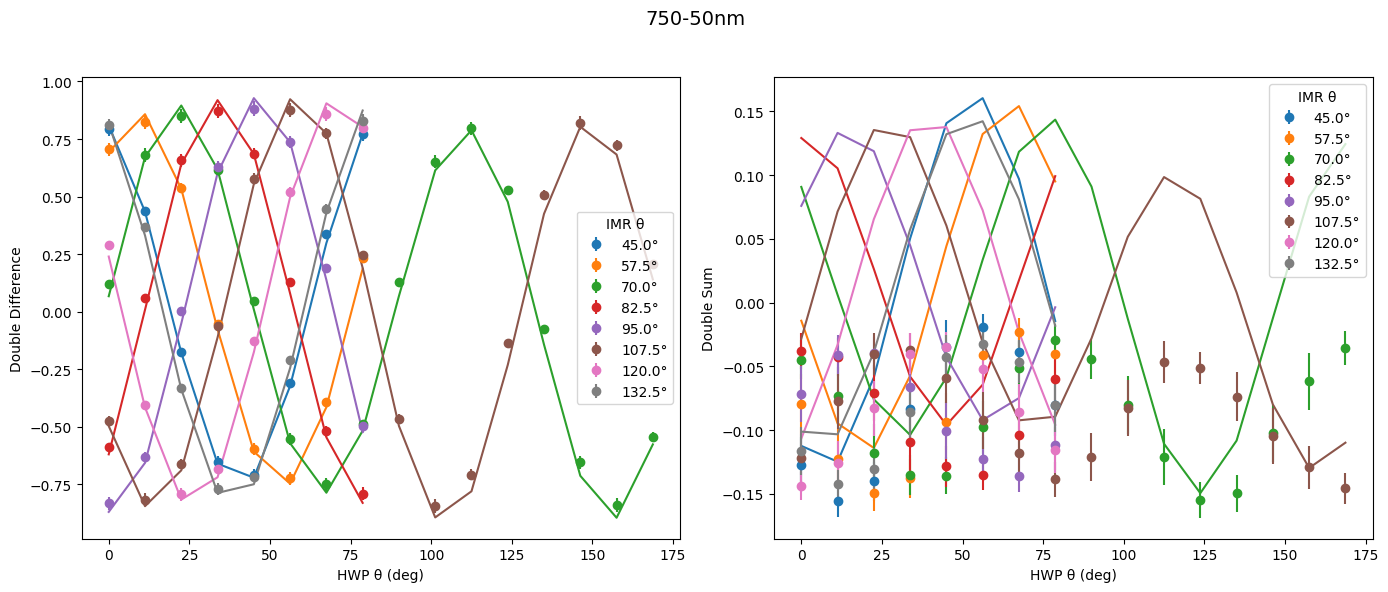

In [6]:
# Fittin for all parameters
p0 = {
    "dichroic": {"phi": 0, 
                 "epsilon": 0, 
                 "theta": 0},
    "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
    "image_rotator": {
                    "phi":delta_derot, 
                    "delta_theta": offset_derot
                    },
    "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol}
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.5231674749347714, 'delta_theta': 2.547063907771257}, 'optics': {'phi': 0.8366868576245823, 'epsilon': 3.887450379959534e-09, 'theta': -59.919309379978884}, 'image_rotator': {'phi': 3.0680237129197785, 'delta_theta': 0}, 'hwp': {'phi': 2.9838983981947838, 'delta_theta': 0.5155838549975353}, 'lp': {'theta': 0.674229408746958}}
Iteration #: 1
logl_value: 189.5871818848004
Best Fit Parameters: [-5.70563879e-03  9.29846577e-02 -1.15108808e-01  3.28108332e+00
 -1.00484239e+00  1.05635645e+00  2.40694052e-08 -7.24295234e+01
  3.07596498e+00  2.45553026e-01  2.99236561e+00  3.65647250e+00
  3.45462986e+00]


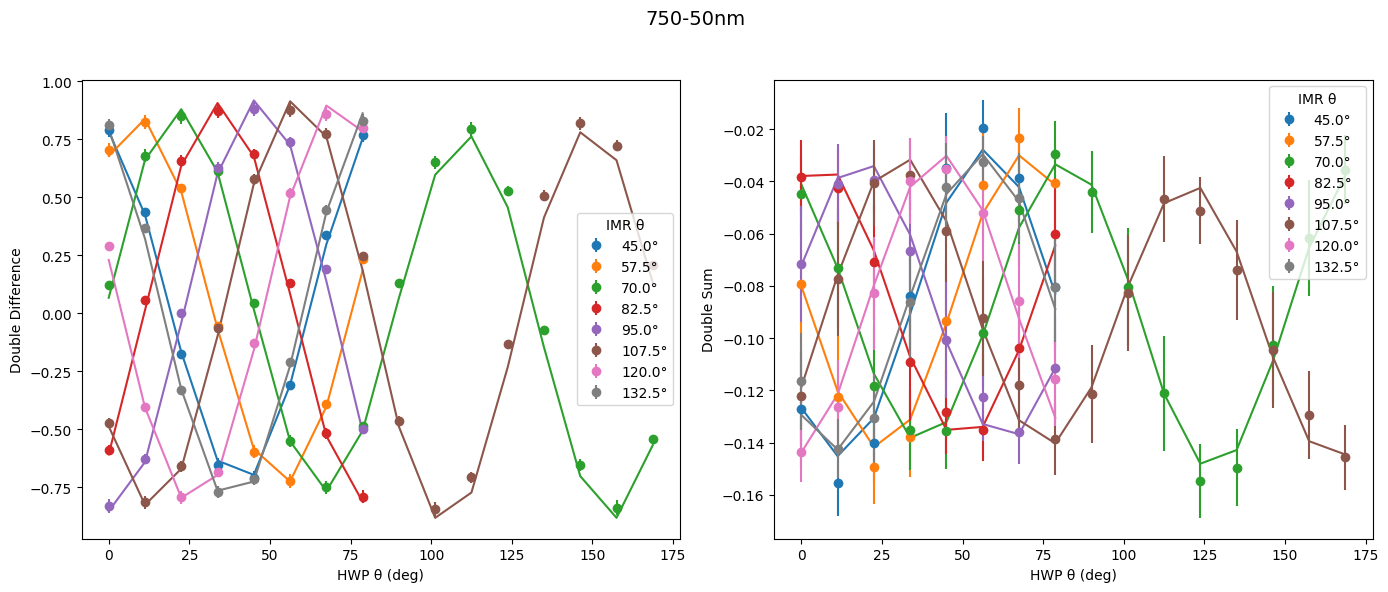

After p0: {'dichroic': {'phi': -0.005705638788114347, 'epsilon': 0.0929846577140952, 'theta': -0.11510880763770481}, 'flc': {'phi': 3.2810833236381516, 'delta_theta': -1.004842388662306}, 'optics': {'phi': 1.05635645181055, 'epsilon': 2.4069405182353265e-08, 'theta': -72.4295233950051}, 'image_rotator': {'phi': 3.0759649819429153, 'delta_theta': 0.24555302551754132}, 'hwp': {'phi': 2.992365606296472, 'delta_theta': 3.656472495019587}, 'lp': {'theta': 3.454629863854656}}
Before p0: {'dichroic': {'phi': -0.005705638788114347, 'epsilon': 0.0929846577140952, 'theta': -0.11510880763770481}, 'flc': {'phi': 3.2810833236381516, 'delta_theta': -1.004842388662306}, 'optics': {'phi': 1.05635645181055, 'epsilon': 2.4069405182353265e-08, 'theta': -72.4295233950051}, 'image_rotator': {'phi': 3.0759649819429153, 'delta_theta': 0.24555302551754132}, 'hwp': {'phi': 2.992365606296472, 'delta_theta': 3.656472495019587}, 'lp': {'theta': 3.454629863854656}}
Iteration #: 2
logl_value: 185.94393210419761
Bes

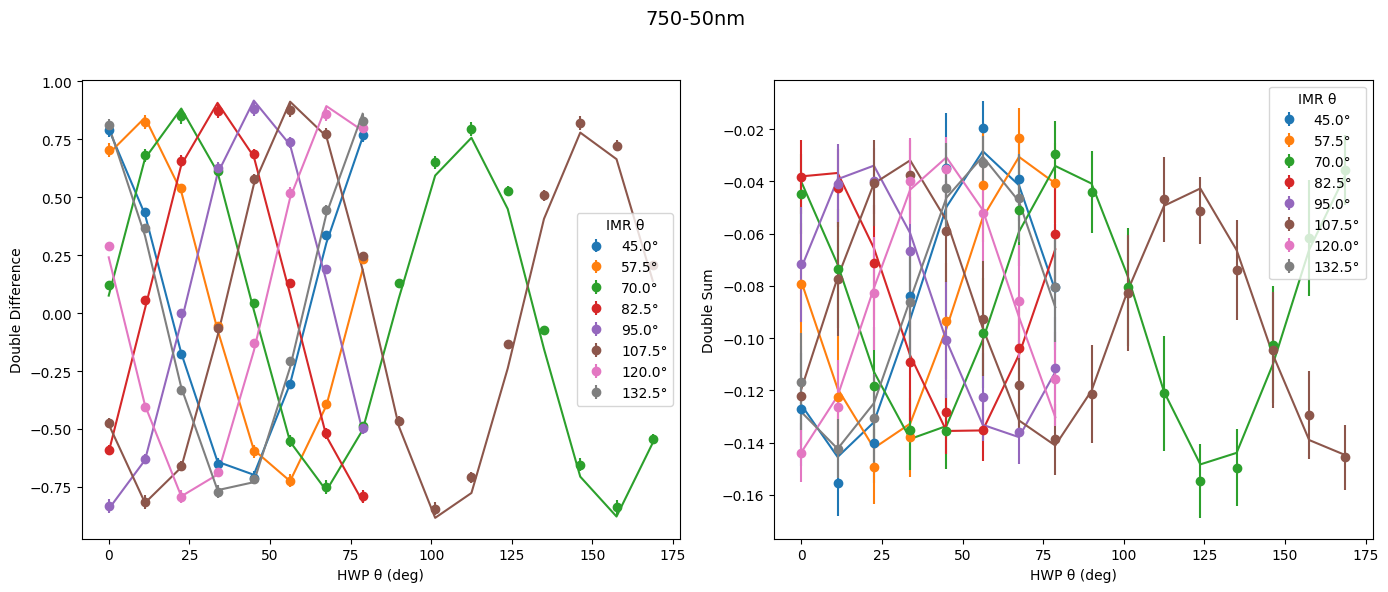

After p0: {'dichroic': {'phi': -0.2233635847285806, 'epsilon': 0.09471061501420672, 'theta': -5.202778263477965}, 'flc': {'phi': 3.1909279530982673, 'delta_theta': 1.8748075865011464}, 'optics': {'phi': 1.0633721598536297, 'epsilon': 0.0, 'theta': -68.0161993304402}, 'image_rotator': {'phi': 3.0722687249273575, 'delta_theta': 0.9687644357870286}, 'hwp': {'phi': 2.989475853349406, 'delta_theta': -3.267248358172174}, 'lp': {'theta': -4.984026531066725}}
Before p0: {'dichroic': {'phi': -0.2233635847285806, 'epsilon': 0.09471061501420672, 'theta': -5.202778263477965}, 'flc': {'phi': 3.1909279530982673, 'delta_theta': 1.8748075865011464}, 'optics': {'phi': 1.0633721598536297, 'epsilon': 0.0, 'theta': -68.0161993304402}, 'image_rotator': {'phi': 3.0722687249273575, 'delta_theta': 0.9687644357870286}, 'hwp': {'phi': 2.989475853349406, 'delta_theta': -3.267248358172174}, 'lp': {'theta': -4.984026531066725}}
Iteration #: 3
logl_value: 29.9167476517163
Best Fit Parameters: [-1.72412729e+00  9.29

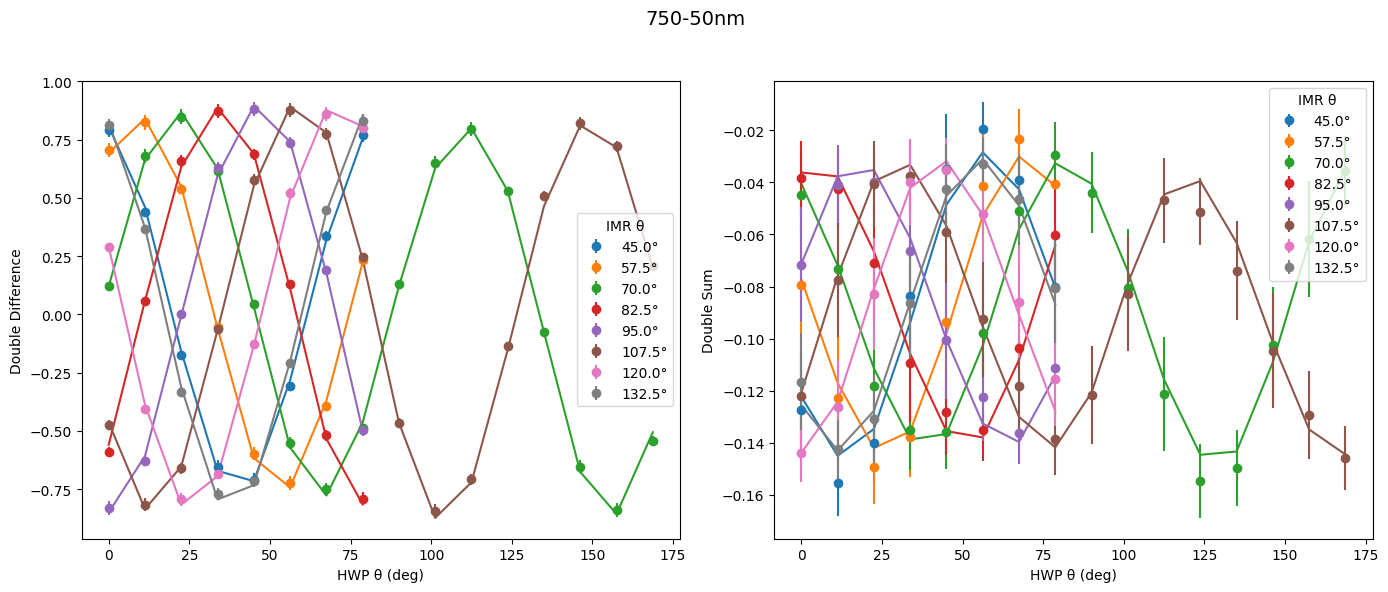

After p0: {'dichroic': {'phi': -1.7241272863896808, 'epsilon': 0.09291639271726763, 'theta': -4.394668683607694}, 'flc': {'phi': 2.9877447737102942, 'delta_theta': -1.3859464624573063}, 'optics': {'phi': 0.8670492286004513, 'epsilon': 0.06587593889078669, 'theta': -68.7385154461158}, 'image_rotator': {'phi': 3.0751649954160065, 'delta_theta': -0.7359810352924208}, 'hwp': {'phi': 3.046111016589717, 'delta_theta': -2.9382416452287696}, 'lp': {'theta': -2.904589224923262}}
Before p0: {'dichroic': {'phi': -1.7241272863896808, 'epsilon': 0.09291639271726763, 'theta': -4.394668683607694}, 'flc': {'phi': 2.9877447737102942, 'delta_theta': -1.3859464624573063}, 'optics': {'phi': 0.8670492286004513, 'epsilon': 0.06587593889078669, 'theta': -68.7385154461158}, 'image_rotator': {'phi': 3.0751649954160065, 'delta_theta': -0.7359810352924208}, 'hwp': {'phi': 3.046111016589717, 'delta_theta': -2.9382416452287696}, 'lp': {'theta': -2.904589224923262}}
Iteration #: 4
logl_value: 26.017072424439725
Bes

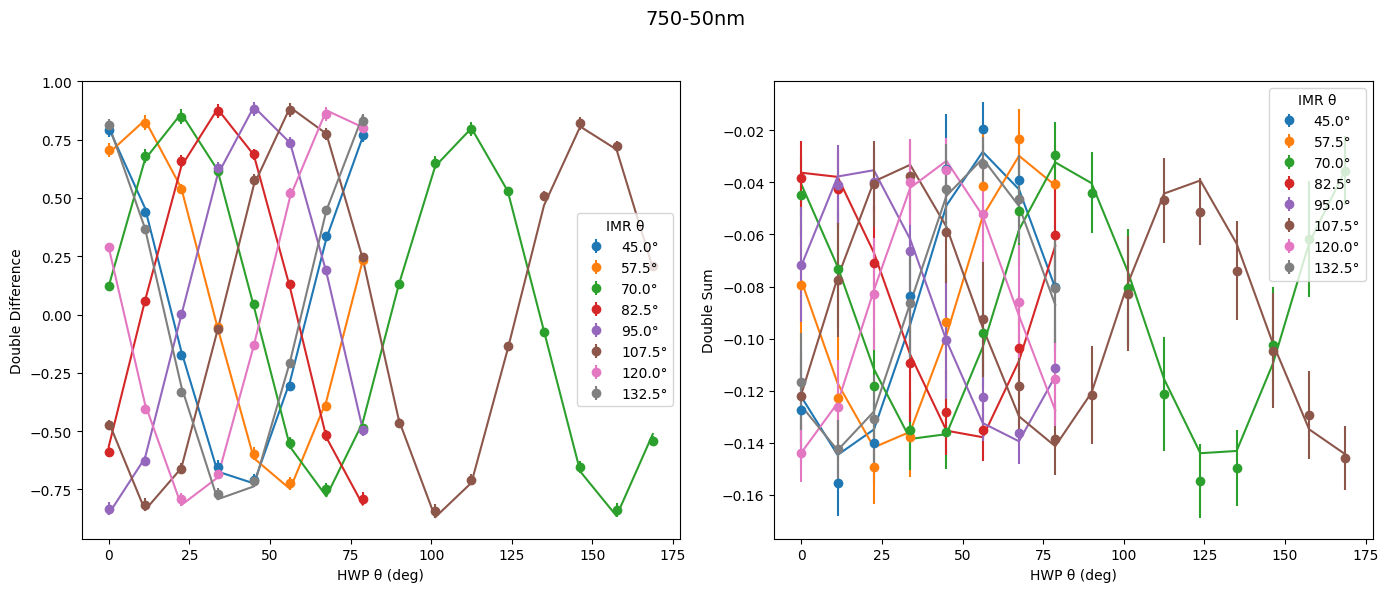

After p0: {'dichroic': {'phi': -2.2919518031974286, 'epsilon': 0.09214161280150818, 'theta': -1.0313404406143412}, 'flc': {'phi': 3.214180211281236, 'delta_theta': 0.4531172866490942}, 'optics': {'phi': 1.0810470023644707, 'epsilon': 0.06886837521658454, 'theta': -69.33145362051955}, 'image_rotator': {'phi': 3.0792550943576966, 'delta_theta': -0.8801068138028569}, 'hwp': {'phi': 3.0470673581862506, 'delta_theta': -1.7388456698574226}, 'lp': {'theta': 0.5008210773596244}}
Before p0: {'dichroic': {'phi': -2.2919518031974286, 'epsilon': 0.09214161280150818, 'theta': -1.0313404406143412}, 'flc': {'phi': 3.214180211281236, 'delta_theta': 0.4531172866490942}, 'optics': {'phi': 1.0810470023644707, 'epsilon': 0.06886837521658454, 'theta': -69.33145362051955}, 'image_rotator': {'phi': 3.0792550943576966, 'delta_theta': -0.8801068138028569}, 'hwp': {'phi': 3.0470673581862506, 'delta_theta': -1.7388456698574226}, 'lp': {'theta': 0.5008210773596244}}
Iteration #: 5
logl_value: 25.817765795144986
B

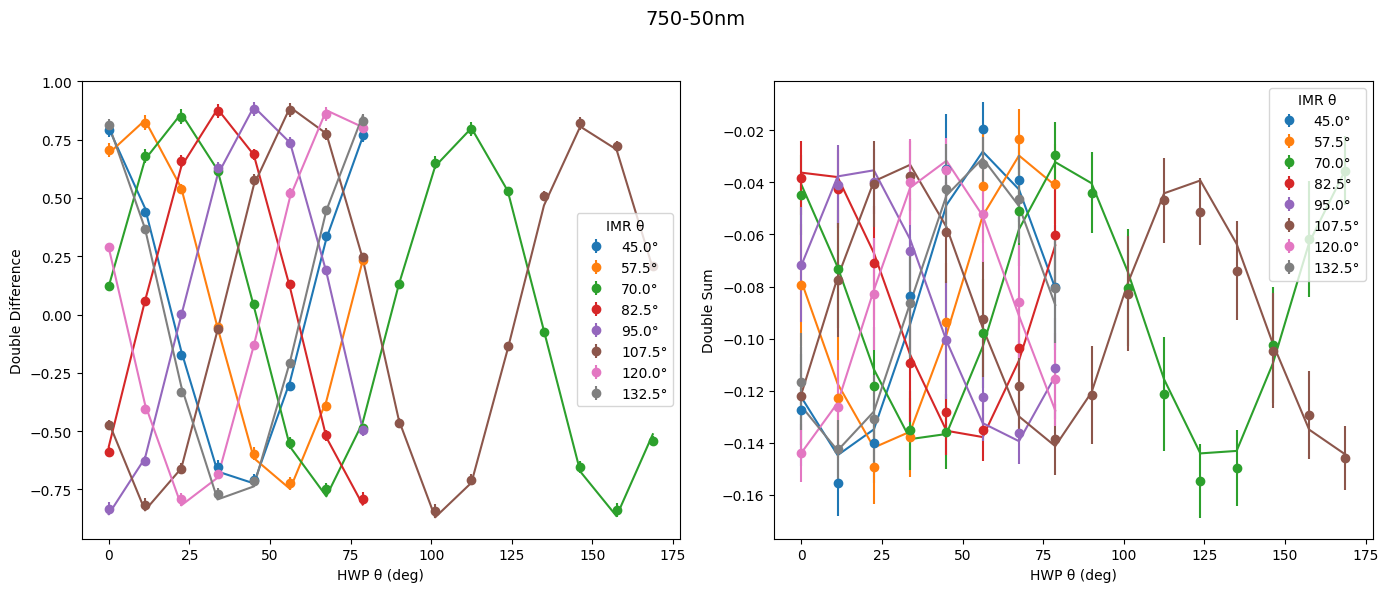

After p0: {'dichroic': {'phi': -1.12634729936643, 'epsilon': 0.09213667482955061, 'theta': -0.7211513949440611}, 'flc': {'phi': 3.2247610235843807, 'delta_theta': 0.8875636750432755}, 'optics': {'phi': 1.0807295869014508, 'epsilon': 0.06910187500867057, 'theta': -69.62711175875525}, 'image_rotator': {'phi': 3.079250623531564, 'delta_theta': -0.999900875251629}, 'hwp': {'phi': 3.0470632498652788, 'delta_theta': -1.1292793528354483}, 'lp': {'theta': 1.4028111582126743}}


In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-np.pi, np.pi),  # delta_opts
    (0, 0.1),  # epsilon_opts
    (-90, 90),  # rot_opts
    ((delta_derot - delta_derot * 0.1), (delta_derot + delta_derot * 0.1)),  # delta_derot
    (-1, 1),  # offset_derot
    ((delta_HWP - delta_HWP * 0.1), (delta_HWP + delta_HWP * 0.1)),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = 1000000
new_logl_value = 0

while abs(previous_logl_value - new_logl_value) > 0.01 * abs(previous_logl_value):
    print("Before p0: " + str(p0))
    if iteration > 1: 
        previous_logl_value = new_logl_value
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    iteration += 1

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_restrictive_HWP_FLC_with_IMR_offset_fixed_EM_gain_with_dichroic_best_fit.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

# Step 6: Plot model with best fit

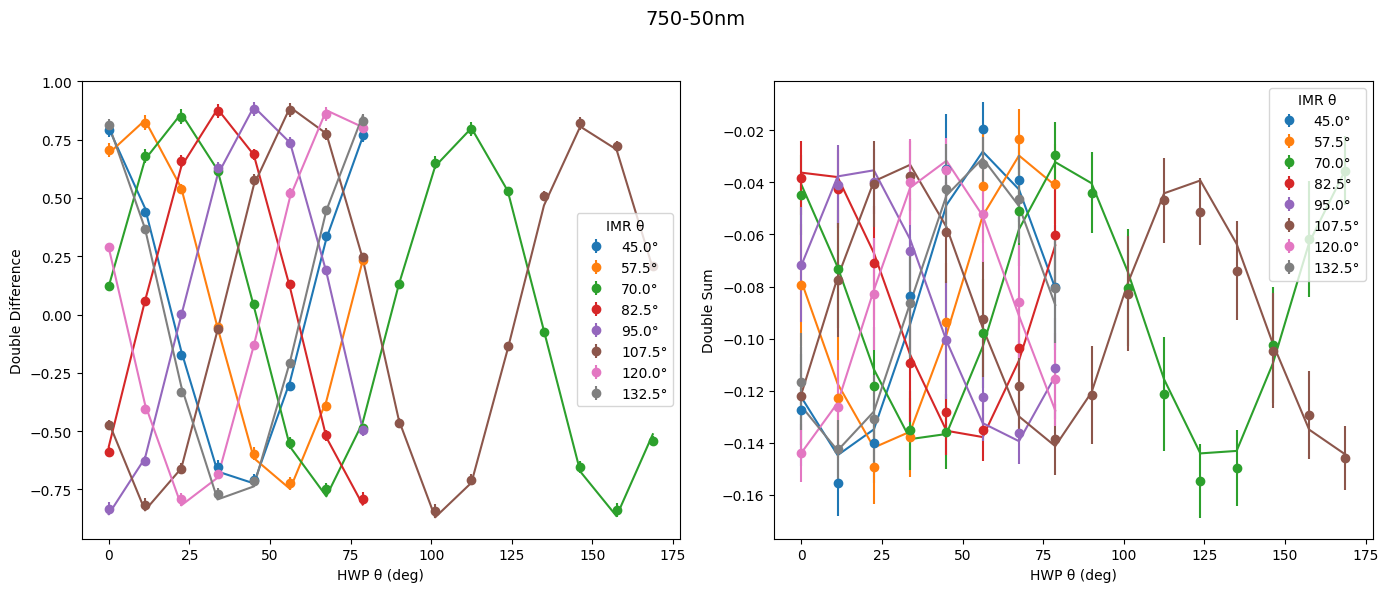

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)